In [2]:
import pandas as pd
import numpy as np

# Set random seed for reproducibility
np.random.seed(42)

# Number of rows
num_rows = 250  # Meeting the minimum 200 rows requirement

# Generate Employee ID
employee_ids = [f"EMP_{i:03d}" for i in range(1, num_rows + 1)]

# Generate Age (between 22 and 60)
age = np.random.randint(22, 61, size=num_rows)

# Generate Gender
gender = np.random.choice(['Male', 'Female', 'Non-binary'], size=num_rows, p=[0.48, 0.48, 0.04])

# Generate Education Level
education_levels = ['Bachelor', 'Master', 'PhD']
education = np.random.choice(education_levels, size=num_rows, p=[0.60, 0.30, 0.10])

# Generate Department
departments = ['IT', 'HR', 'Finance', 'Marketing', 'Operations']
department = np.random.choice(departments, size=num_rows)

# Generate Experience (Logic: Experience must be less than (Age - 18))
experience = []
for a in age:
    max_exp = max(0, a - 22)  # Assuming they finished college at 22
    exp = np.random.randint(0, max_exp + 1) if max_exp > 0 else 0
    experience.append(exp)
experience = np.array(experience)

# Generate Working Hours per week (mostly around 40 hours)
working_hours = np.random.normal(loc=40, scale=4, size=num_rows).astype(int)
working_hours = np.clip(working_hours, 30, 60)  # Bound between 30 and 60 hours

# Generate Performance Score (1 to 5 scale)
performance_score = np.random.choice([1, 2, 3, 4, 5], size=num_rows, p=[0.1, 0.2, 0.4, 0.2, 0.1])

# Generate Projects Completed (Correlated somewhat with experience and performance)
projects_completed = (experience * 1.5 + performance_score * 2 + np.random.randint(0, 5, size=num_rows)).astype(int)

# Generate Salary using a logical base formula + noise
# Base salary $40,000 + experience ($3,000/yr) + education bonus + performance bonus
base_salary = 40000
edu_bonus = np.array([0 if e == 'Bachelor' else 12000 if e == 'Master' else 25000 for e in education])
dept_bonus = np.array([5000 if d in ['IT', 'Finance'] else 0 for d in department])

salary = (
    base_salary
    + (experience * 3500)
    + edu_bonus
    + dept_bonus
    + (performance_score * 4000)
    + ((working_hours - 40) * 500)  # Overtime pay/under-time penalty
    + np.random.normal(0, 3000, size=num_rows)  # Random market noise
)
# Ensure no unrealistic salaries
salary = np.round(np.clip(salary, 35000, 180000), -2).astype(int)

# Create DataFrame
df = pd.DataFrame({
    'Employee_ID': employee_ids,
    'Age': age,
    'Gender': gender,
    'Education': education,
    'Department': department,
    'Experience': experience,
    'Working_Hours': working_hours,
    'Performance_Score': performance_score,
    'Projects_Completed': projects_completed,
    'Salary': salary
})

# Save to CSV
csv_filename = "employee_salary_dataset.csv"
df.to_csv(csv_filename, index=False)

print(f"Successfully generated custom dataset with {df.shape[0]} rows and {df.shape[1]} columns.")
print(f"Saved as '{csv_filename}'")

Successfully generated custom dataset with 250 rows and 10 columns.
Saved as 'employee_salary_dataset.csv'


In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# 1. Load the dataset
# (Replacing missing values with NaN to simulate a real preprocessing pipeline)
df = pd.read_csv("employee_salary_dataset.csv")

print("--- Initial Data Info ---")
print(f"Dataset Shape: {df.shape}")

# --- 2. Handle Missing Values ---
# Even though our generated data is clean, a robust pipeline always checks for this.
# If missing values exist, we fill numeric with median and categorical with mode.
numeric_cols = df.select_dtypes(include=[np.number]).columns
categorical_cols = df.select_dtypes(include=['object']).columns

for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)

print(f"Missing values after handling: {df.isnull().sum().sum()}")

# --- 3. Remove Duplicates ---
initial_rows = df.shape[0]
df.drop_duplicates(inplace=True)
print(f"Removed {initial_rows - df.shape[0]} duplicate rows.")

# --- 4. Separate Features (X) and Target Variable (y) ---
# We drop 'Employee_ID' because unique identifiers don't carry predictive power.
X = df.drop(columns=['Employee_ID', 'Salary'])
y = df['Salary']

# Define which columns need what type of processing
num_features = ['Age', 'Experience', 'Working_Hours', 'Performance_Score', 'Projects_Completed']
cat_features = ['Gender', 'Education', 'Department']

# --- 5. Encode Categorical Values & Feature Scaling ---
# We use a ColumnTransformer to handle both steps efficiently in parallel.
# - OneHotEncoder converts categories into binary columns (dropping first to avoid dummy variable trap).
# - StandardScaler scales numerical features so they have a mean of 0 and variance of 1.

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_features)
    ]
)

# Apply the transformations to features
X_processed = preprocessor.fit_transform(X)

# Get the updated column names after One-Hot Encoding for visualization
encoded_cat_names = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_features)
all_feature_names = num_features + list(encoded_cat_names)

# Convert back to a DataFrame just to inspect the results cleanly
X_processed_df = pd.DataFrame(X_processed, columns=all_feature_names)

# --- 6. Perform Train-Test Split ---
# 80% of the data will be used for training, and 20% for testing.
X_train, X_test, y_train, y_test = train_test_split(X_processed_df, y, test_size=0.2, random_state=42)

print("\n--- Preprocessing Complete ---")
print(f"Training feature shape: {X_train.shape}")
print(f"Testing feature shape: {X_test.shape}")

--- Initial Data Info ---
Dataset Shape: (250, 10)
Missing values after handling: 0
Removed 0 duplicate rows.

--- Preprocessing Complete ---
Training feature shape: (200, 13)
Testing feature shape: (50, 13)


In [4]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, classification_report

# --- Preparation for Categorical Target (for Logistic Regression) ---
# We will use quantiles to divide the continuous salaries into 3 distinct categories.
# Low: Bottom 33%, Medium: Middle 33%, High: Top 34%
low_thresh = y_train.quantile(0.33)
high_thresh = y_train.quantile(0.66)

def categorize_salary(salary):
    if salary <= low_thresh:
        return 'Low Salary'
    elif salary <= high_thresh:
        return 'Medium Salary'
    else:
        return 'High Salary'

# Create categorical targets for classification tasks
y_train_cat = y_train.apply(categorize_salary)
y_test_cat = y_test.apply(categorize_salary)


# ==========================================
# A. LINEAR REGRESSION (Predict Exact Salary)
# ==========================================
print("--- A. Linear Regression Results ---")
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict and Evaluate
y_pred_lr = lr_model.predict(X_test)
lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_r2 = r2_score(y_test, y_pred_lr)

print(f"Mean Absolute Error (MAE): ${lr_mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): ${lr_rmse:,.2f}")
print(f"R² Score (Variance Explained): {lr_r2:.4f}\n")


# ============================================
# B. LOGISTIC REGRESSION (Classify Categories)
# ============================================
print("--- B. Logistic Regression Results ---")
# Using multi_class='multinomial' for 3-class classification
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train_cat)

# Predict and Evaluate
y_pred_log = log_reg.predict(X_test)
log_acc = accuracy_score(y_test_cat, y_pred_log)

print(f"Classification Accuracy: {log_acc * 100:.2f}%")
print("Classification Report:")
print(classification_report(y_test_cat, y_pred_log))


# ========================================
# C. RANDOM FOREST (Regression & Classification)
# ========================================
print("--- C. Random Forest Results ---")

# 1. Random Forest Regressor (To compare with Linear Regression)
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train, y_train)
y_pred_rf_reg = rf_reg.predict(X_test)

rf_mae = mean_absolute_error(y_test, y_pred_rf_reg)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf_reg))
rf_reg_r2 = r2_score(y_test, y_pred_rf_reg)

print("[Random Forest Regressor - Exact Salary]")
print(f"Mean Absolute Error (MAE): ${rf_mae:,.2f}")
print(f"R² Score: {rf_reg_r2:.4f}\n")

# 2. Random Forest Classifier (To compare with Logistic Regression)
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train_cat)
y_pred_rf_clf = rf_clf.predict(X_test)

rf_clf_acc = accuracy_score(y_test_cat, y_pred_rf_clf)
print("[Random Forest Classifier - Salary Categories]")
print(f"Classification Accuracy: {rf_clf_acc * 100:.2f}%\n")


# ==========================================
# PERFORMANCE COMPARISON SUMMARY TABLES
# ==========================================
print("==============================================")
print("             MODEL COMPARISON SUMMARY         ")
print("==============================================")

regression_comparison = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R² Score'],
    'Linear Regression': [f"${lr_mae:,.2f}", f"${lr_rmse:,.2f}", f"{lr_r2:.4f}"],
    'Random Forest Regressor': [f"${rf_mae:,.2f}", f"${rf_rmse:,.2f}", f"{rf_reg_r2:.4f}"]
})

classification_comparison = pd.DataFrame({
    'Metric': ['Accuracy'],
    'Logistic Regression': [f"{log_acc * 100:.2f}%"],
    'Random Forest Classifier': [f"{rf_clf_acc * 100:.2f}%"]
})

print("\n[Continuous Value Prediction Comparison]")
print(regression_comparison.to_string(index=False))

print("\n[Categorical Class Prediction Comparison]")
print(classification_comparison.to_string(index=False))

--- A. Linear Regression Results ---
Mean Absolute Error (MAE): $2,135.59
Root Mean Squared Error (RMSE): $2,559.63
R² Score (Variance Explained): 0.9939

--- B. Logistic Regression Results ---
Classification Accuracy: 90.00%
Classification Report:
               precision    recall  f1-score   support

  High Salary       1.00      0.86      0.92        14
   Low Salary       0.90      0.95      0.92        19
Medium Salary       0.83      0.88      0.86        17

     accuracy                           0.90        50
    macro avg       0.91      0.90      0.90        50
 weighted avg       0.91      0.90      0.90        50

--- C. Random Forest Results ---
[Random Forest Regressor - Exact Salary]
Mean Absolute Error (MAE): $6,255.54
R² Score: 0.9459

[Random Forest Classifier - Salary Categories]
Classification Accuracy: 86.00%

             MODEL COMPARISON SUMMARY         

[Continuous Value Prediction Comparison]
  Metric Linear Regression Random Forest Regressor
     MAE      

/tmp/ipykernel_9060/826101929.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Department', y='Salary', palette='Set2', ax=axes[1, 1])
/tmp/ipykernel_9060/826101929.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp_df, x='Importance', y='Feature', palette='viridis', ax=axes[2, 0])


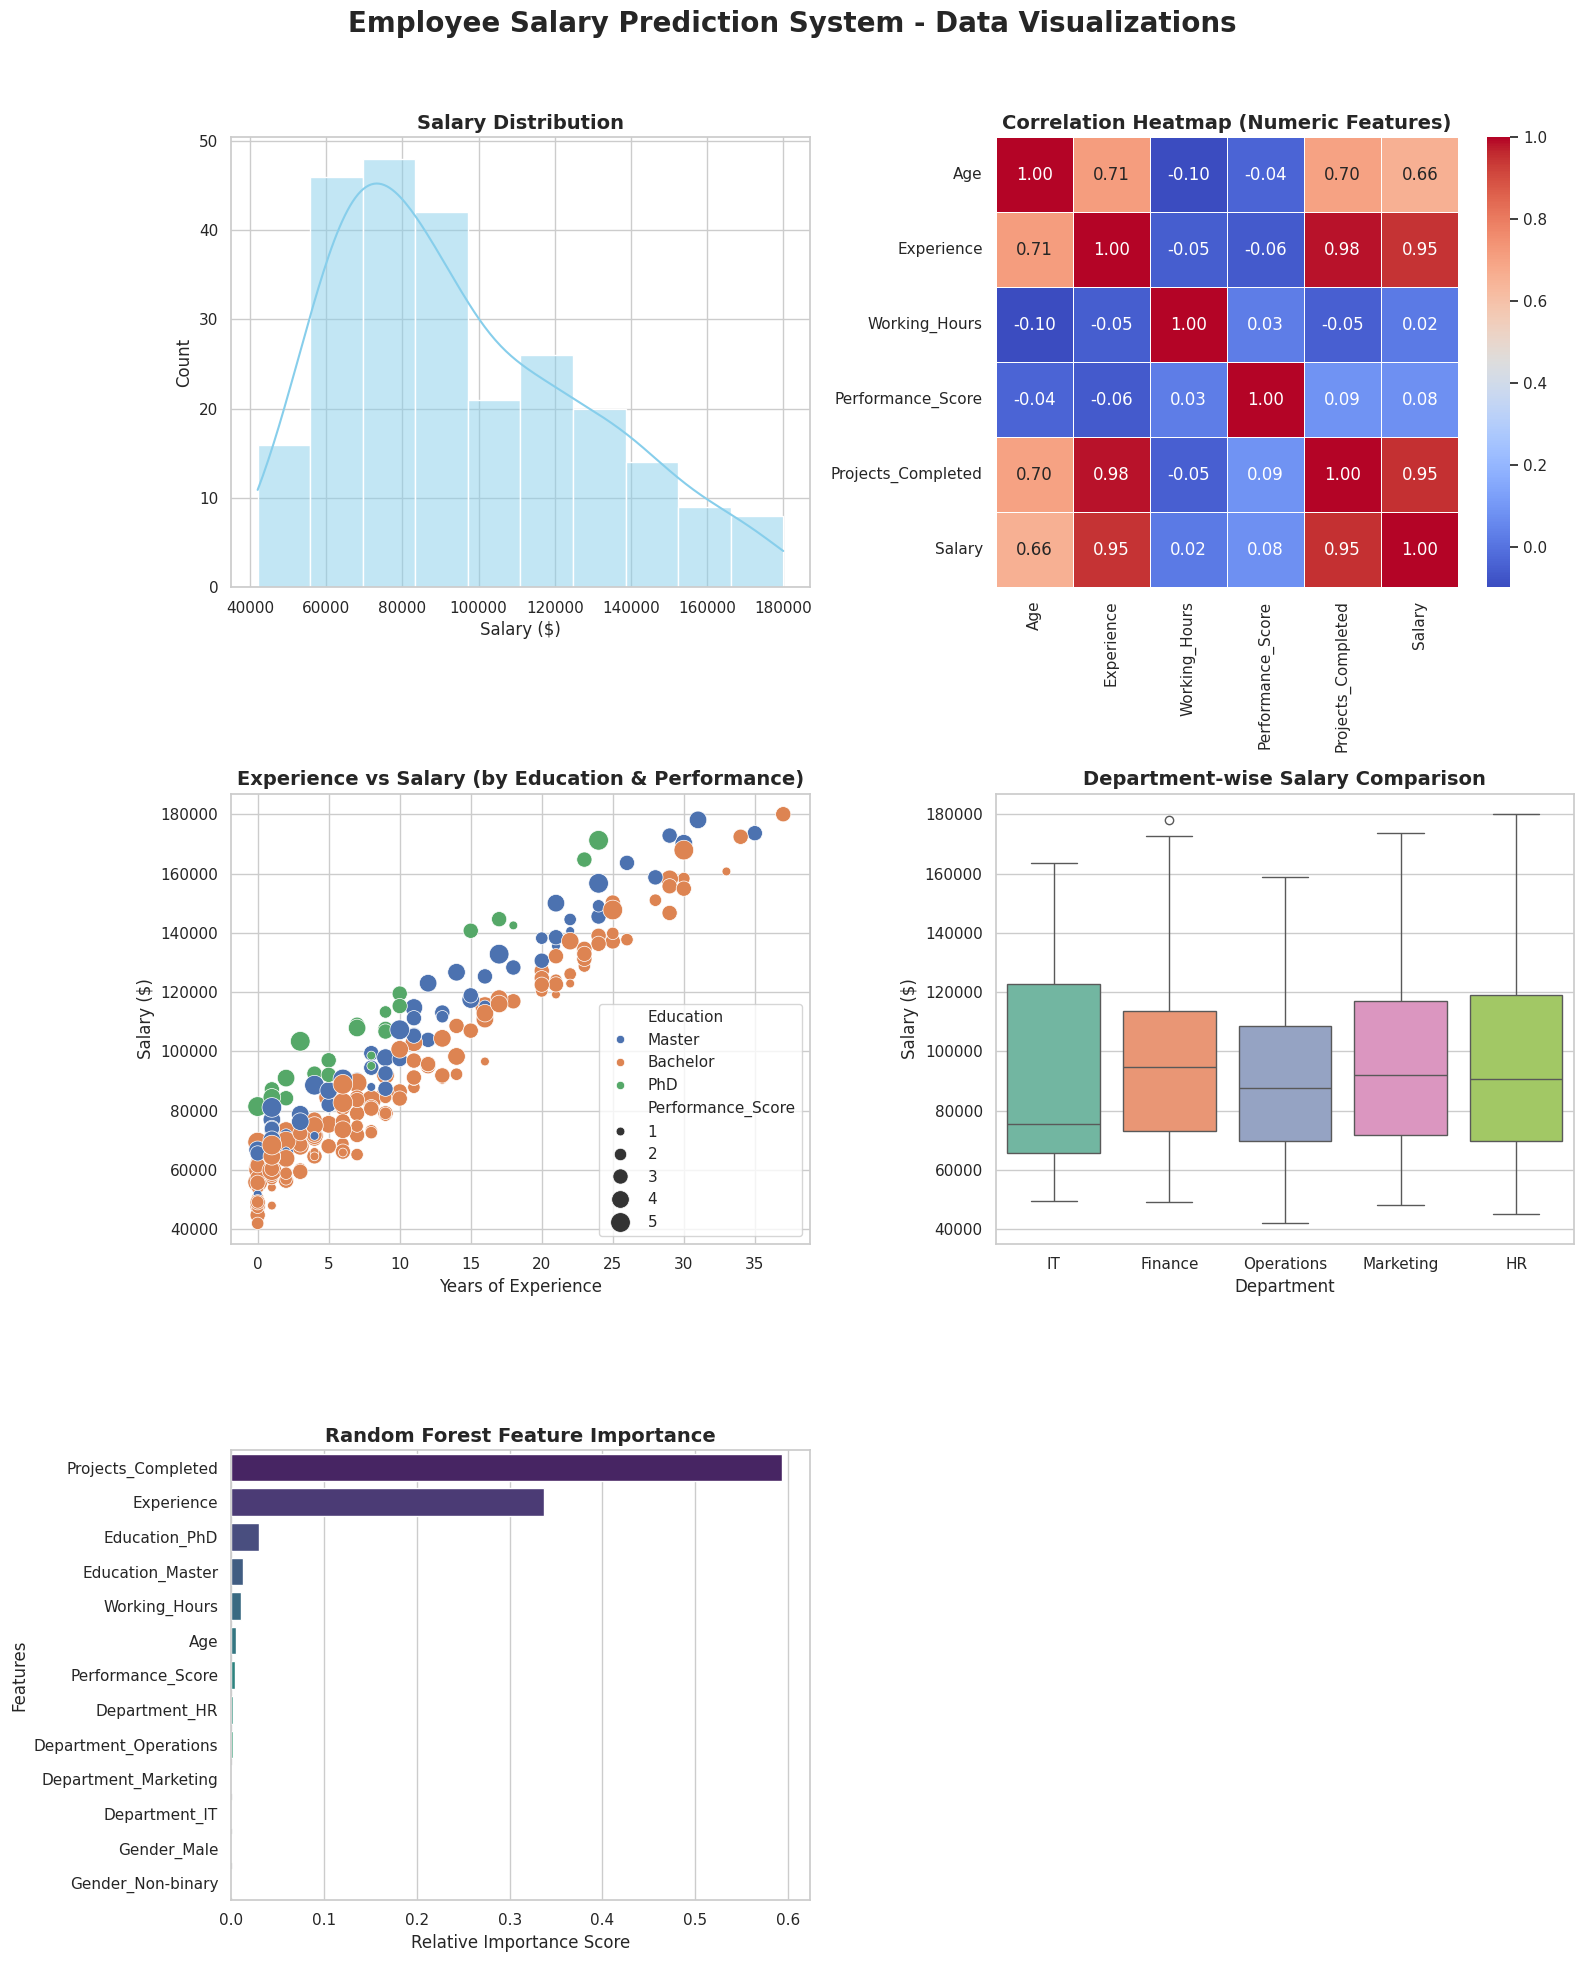

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor

# 1. Load the generated dataset
df = pd.read_csv("employee_salary_dataset.csv")

# Set up global plotting aesthetics
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 2, figsize=(16, 20))
fig.suptitle('Employee Salary Prediction System - Data Visualizations', fontsize=20, weight='bold', y=0.98)

# ==========================================
# GRAPH 1: Salary Distribution
# ==========================================
sns.histplot(df['Salary'], kde=True, color='skyblue', ax=axes[0, 0])
axes[0, 0].set_title('Salary Distribution', fontsize=14, weight='bold')
axes[0, 0].set_xlabel('Salary ($)')
axes[0, 0].set_ylabel('Count')

# ==========================================
# GRAPH 2: Correlation Heatmap
# ==========================================
numeric_features = ['Age', 'Experience', 'Working_Hours', 'Performance_Score', 'Projects_Completed', 'Salary']
corr = df[numeric_features].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, ax=axes[0, 1])
axes[0, 1].set_title('Correlation Heatmap (Numeric Features)', fontsize=14, weight='bold')

# ==========================================
# GRAPH 3: Experience vs Salary
# ==========================================
sns.scatterplot(
    data=df, x='Experience', y='Salary',
    hue='Education', palette='deep',
    size='Performance_Score', sizes=(40, 200), ax=axes[1, 0]
)
axes[1, 0].set_title('Experience vs Salary (by Education & Performance)', fontsize=14, weight='bold')
axes[1, 0].set_xlabel('Years of Experience')
axes[1, 0].set_ylabel('Salary ($)')

# ==========================================
# GRAPH 4: Department-wise Comparison
# ==========================================
sns.boxplot(data=df, x='Department', y='Salary', palette='Set2', ax=axes[1, 1])
axes[1, 1].set_title('Department-wise Salary Comparison', fontsize=14, weight='bold')
axes[1, 1].set_xlabel('Department')
axes[1, 1].set_ylabel('Salary ($)')

# ==========================================
# GRAPH 5: Feature Importance Graph
# ==========================================
# Extracting feature importances using Random Forest
X = df.drop(columns=['Employee_ID', 'Salary'])
y = df['Salary']
num_cols = ['Age', 'Experience', 'Working_Hours', 'Performance_Score', 'Projects_Completed']
cat_cols = ['Gender', 'Education', 'Department']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols)
    ]
)
X_processed = preprocessor.fit_transform(X)
encoded_names = num_cols + list(preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols))

# Fit temporary forest to gather data positions
rf = RandomForestRegressor(n_estimators=100, random_state=42).fit(X_processed, y)

feat_imp_df = pd.DataFrame({'Feature': encoded_names, 'Importance': rf.feature_importances_})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False)

sns.barplot(data=feat_imp_df, x='Importance', y='Feature', palette='viridis', ax=axes[2, 0])
axes[2, 0].set_title('Random Forest Feature Importance', fontsize=14, weight='bold')
axes[2, 0].set_xlabel('Relative Importance Score')
axes[2, 0].set_ylabel('Features')

# Remove the empty 6th subplot grid space to keep things clean
fig.delaxes(axes[2, 1])

# Render and Save
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('salary_visualizations.png', dpi=300)
plt.show()

             REGRESSION MODEL PERFORMANCE                 
                        Metric Linear Regression Random Forest Regressor
     Mean Absolute Error (MAE)         $2,135.59               $6,255.54
      Mean Squared Error (MSE)     $6,551,684.59          $57,707,541.62
Root Mean Squared Error (RMSE)         $2,559.63               $7,596.55
                      R² Score            0.9939                  0.9459

            CLASSIFICATION MODEL PERFORMANCE              
        Metric Logistic Regression Random Forest Classifier
Accuracy Score              90.00%                   86.00%


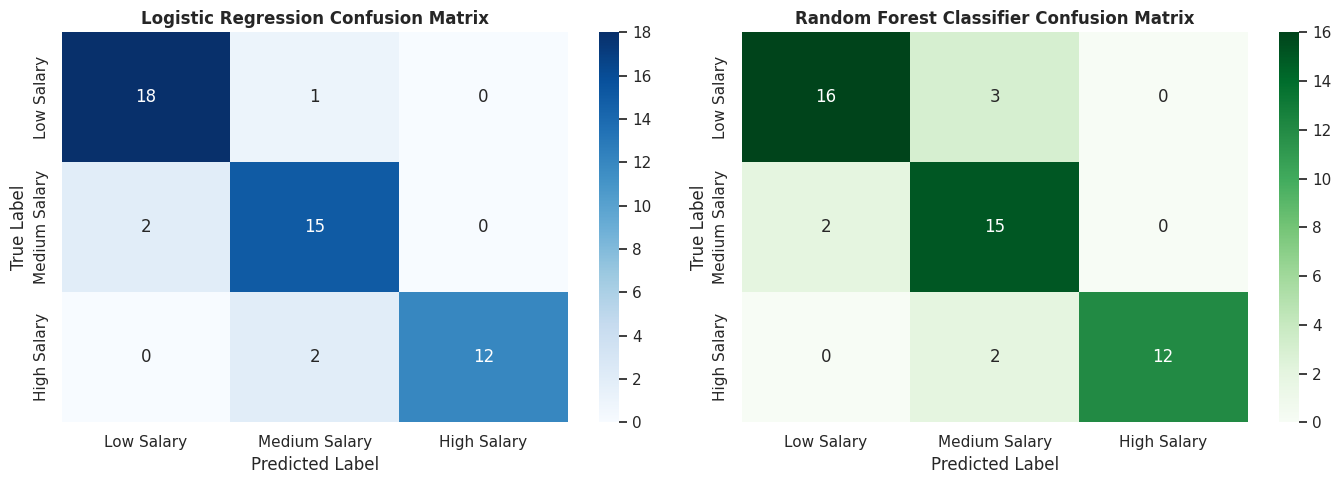

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, mean_absolute_error, mean_squared_error, r2_score,
    confusion_matrix, classification_report
)

# Note: This script assumes variables from Step 3 (y_test, y_pred_lr, y_pred_rf_reg,
# y_test_cat, y_pred_log, y_pred_rf_clf) are loaded in your environment.

# --- 1. CONTINUOUS VALUE EVALUATION (Regression Models) ---
# Evaluating Linear Regression vs Random Forest Regressor
metrics_reg = {
    'Metric': ['Mean Absolute Error (MAE)', 'Mean Squared Error (MSE)', 'Root Mean Squared Error (RMSE)', 'R² Score'],
    'Linear Regression': [
        mean_absolute_error(y_test, y_pred_lr),
        mean_squared_error(y_test, y_pred_lr),
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        r2_score(y_test, y_pred_lr)
    ],
    'Random Forest Regressor': [
        mean_absolute_error(y_test, y_pred_rf_reg),
        mean_squared_error(y_test, y_pred_rf_reg),
        np.sqrt(mean_squared_error(y_test, y_pred_rf_reg)),
        r2_score(y_test, y_pred_rf_reg)
    ]
}

df_reg_eval = pd.DataFrame(metrics_reg)


# --- 2. CATEGORICAL VALUE EVALUATION (Classification Models) ---
# Evaluating Logistic Regression vs Random Forest Classifier
log_acc = accuracy_score(y_test_cat, y_pred_log)
rf_clf_acc = accuracy_score(y_test_cat, y_pred_rf_clf)

df_clf_eval = pd.DataFrame({
    'Metric': ['Accuracy Score'],
    'Logistic Regression': [f"{log_acc * 100:.2f}%"],
    'Random Forest Classifier': [f"{rf_clf_acc * 100:.2f}%"]
})


# --- PRINT EVALUATION TABLES ---
print("==========================================================")
print("             REGRESSION MODEL PERFORMANCE                 ")
print("==========================================================")
# Formatting for clean dollar representations
df_reg_formatted = df_reg_eval.copy()
for col in ['Linear Regression', 'Random Forest Regressor']:
    df_reg_formatted[col] = df_reg_formatted.apply(
        lambda row: f"{row[col]:.4f}" if row['Metric'] == 'R² Score' else f"${row[col]:,.2f}", axis=1
    )
print(df_reg_formatted.to_string(index=False))

print("\n==========================================================")
print("            CLASSIFICATION MODEL PERFORMANCE              ")
print("==========================================================")
print(df_clf_eval.to_string(index=False))


# --- 3. CONFUSION MATRIX VISUALIZATION ---
# Generating matrices to show where the classification models misclassified brackets
labels = ['Low Salary', 'Medium Salary', 'High Salary']
cm_log = confusion_matrix(y_test_cat, y_pred_log, labels=labels)
cm_rf = confusion_matrix(y_test_cat, y_pred_rf_clf, labels=labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Logistic Regression Confusion Matrix
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title('Logistic Regression Confusion Matrix', fontsize=12, weight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# Plot Random Forest Classifier Confusion Matrix
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_title('Random Forest Classifier Confusion Matrix', fontsize=12, weight='bold')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=300)
plt.show()